### 1. Dependencies

In [157]:
import numpy as np
import pandas as pd
from itertools import chain
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


#functions
from functions.functions import low_high, set_first_row_to_zero
from functions.portfolio_strategy_design.univariate_sorting_preprocess import prepare_univariate_sorting_inputs
from functions.data_functions.get_data import get_row_universe, get_usa_universe, get_processed_fx_rates, get_famafrench_factors, get_processed_index
from functions.data_functions.process_data import process_row_universe, process_usa_universe, process_global_universe

In [158]:
# MANUAL INPUT
download_wrds_data = False#True
download_ff_data = False#True
esg_choice = 'none'               # 's&p' or 'refinitiv' or 'none'
start_year = 2013                 # these ESG sources are aligned for `start_year==2013`
end_year = 2024

#sector split
top_x_by_industry_even_split = 12

#Univariate Sorting
no_simple_quantiles = 6
# Thresholds
# default: alpha_bound = 0.05
alpha_bound = 0.1    # percentage of extremes to exclude from the GOLDEN data
mktcap_covered = 0.95 # target market cap coverage per currency area # Filters bottom 5% of market cap

Signal Design

In [159]:
#signal_type = "all_SDG_1D" # all_sdgs" # "people" # "people" #"planet"#"people"#"all_actions" # #

Filters

In [209]:
#currencies we keep
currency_filter = ['EUR', 'USD'] #['CHF', 'GBP', 'EUR', 'USD'])]
# region_filter = ["United States and Canada"]

execute_location_filters = False
loc_filter = ["USA"]

drop_real_estate = True


### 2. Data

Golden Data

In [161]:
#Golden Dataset Location
golden_location = "C:/Users/chris/Documents/GitHub/data/Golden_Data"


# Golden Dataset
#lc = pd.read_csv(f'{golden_location}/LC_dataset_v_2A.csv')
lc = pd.read_csv(f'{golden_location}/LC_dataset_v_2B1_20260409.csv')

# if signal_type != "all_actions":
#     # #3d counts
#     lc_3d  = pd.read_parquet(f"{golden_location}/LC_dataset_v_2A_3d_counts_gen2.parquet")
#     company_data = pd.read_parquet("./data/company_database_20260414.parquet")


#     #Preprocessing for merging
#     cols_to_merge = ['loc', 'MacroRegion', 'GICS_level_1', 'GICS_level_2', 'GICS_level_3', 'gvkey']
#     company_data = company_data.dropna(subset=["gvkey"])
#     lc_3d = lc_3d.dropna(subset=["gvkey"])
#     company_data["gvkey"] = company_data["gvkey"].astype("Int64").astype("string")
#     lc_3d['gvkey'] = lc_3d['gvkey'].astype(int).astype(str)



#     company_dim = company_data[cols_to_merge].drop_duplicates(subset=["gvkey"])
#     lc = lc_3d.merge(company_dim, on="gvkey", how="left", validate="m:1")




#### 2.1 LC dataset

In [162]:
from functions.data_functions.process_lc import process_lc, map_sectors, filter_sum_activities_by_fiscal_year_quantiles

lc = process_lc(lc, start_year, end_year)


if drop_real_estate:
    lc = lc[lc['GICS_level_1'] != 'Real Estate']

#print(lc['GICS_level_1'].unique())
lc['Industry'] = lc['GICS_level_1'].apply(map_sectors)
print("Industries:", lc['Industry'].unique())


# # Filter to keep a stable panel meaning we have initiatives for all years
# gvkey_stable_panel = lc.groupby(['gvkey'])['gvkey'].count() == (lc['rfyear'].max()-lc['rfyear'].min()+1)
# gvkey_stable_panel = gvkey_stable_panel[gvkey_stable_panel].index
# lc = lc[lc['gvkey'].isin(gvkey_stable_panel)]


#FILTER for LC dataset
if execute_location_filters == True:
    lc = lc[lc['loc'].isin(loc_filter)]

# lc = lc[lc["Industry"] == "ICT"]


Industries: ['Industrials' 'Consumer' 'Financial' 'Primary Industries' 'ICT'
 'Health Care' 'Utilities']


In [ ]:
'''
Dictionary specifying types categories

Stakeholders:
  - customers
  - employees
  - enviroment
  - local communities and society
  - nothing
  - shareholders
  - suppliers
'''



signal_0_name = "people"
signal_1_name = "planet"
signal_2_name = "prosperity"

#(14,15) =

# Actions
dict_all_SDG_1D = {
  f'{signal_0_name}, {signal_1_name}, {signal_2_name}':
    {
      'SDG: 1': 0,
      'SDG: 2': 0,
      'SDG: 3': 0,
      'SDG: 4': 0, 

      'SDG: 5': 0,
      'SDG: 8': 0,
      'SDG: 10': 0,

      'SDG: 6': 1,
      'SDG: 7': 1,
      'SDG: 12': 1,
      'SDG: 13': 1,

      'SDG: 14': 1,
      'SDG: 15': 1,  

      'SDG: 9': 2,
      'SDG: 11': 2,
      
      'SDG: 16': 2,
      'SDG: 17': 2, 
  },
}

# MANUAL INPUT
# Choose which action characterization to use
dict_all_SDG_1D = dict_all_SDG_1D[f'{signal_0_name}, {signal_1_name}, {signal_2_name}']

categories_dict = dict_all_SDG_1D

In [164]:
# from functions.signal_design.people_vs_planet import people_vs_planet
# categories_dict_people, categories_dict_planet, categories_dict_people_advocacy, categories_dict_planet_advocacy, categories_dict_prosperity, categories_dict_prosperity_advocacy, categories_dict_all_sdgs, categories_dict_all_sdgs_advocacy = people_vs_planet(categories_dict_actions)


# if signal_type == "all_SDG_1D":
#     categories_dict = dict_all_SDG_1D
# elif signal_type == "people":
#     categories_dict = categories_dict_people
# elif signal_type == "planet":
#     categories_dict = categories_dict_planet
# elif signal_type == "prosperity":
#     categories_dict = categories_dict_prosperity
# elif signal_type == "all_sdgs":
#     categories_dict = categories_dict_all_sdgs


In [165]:
for (key, value) in categories_dict.items():
    if f'sum_with_{value}' in lc.columns:
        lc[f'sum_with_{value}'] += lc[key]
    else:
        lc[f'sum_with_{value}'] = lc[key].values

lc['sum_activities'] = lc.loc[:, list(categories_dict.keys())].sum(axis=1)

In [166]:
lc["sum_activities"].describe()

count    62835.000000
mean        29.495043
std         36.202580
min          2.000000
25%          8.000000
50%         18.000000
75%         37.000000
max        783.000000
Name: sum_activities, dtype: float64

In [167]:
lc = filter_sum_activities_by_fiscal_year_quantiles(
    lc,
    lower_exclude= (alpha_bound/2),
    upper_exclude= (alpha_bound/2),
)

In [168]:
lc["sum_activities"].describe()

count    54709.000000
mean        25.441244
std         21.093187
min          3.000000
25%          9.000000
50%         19.000000
75%         35.000000
max        148.000000
Name: sum_activities, dtype: float64

Create the signal

In [169]:
max_category = max(categories_dict.values())
for i in range(max_category+1):
    lc[f'signal_{i}'] = lc[f'sum_with_{i}'] / lc['sum_activities']

Num stocks in USA and EU prior to some more filters

In [170]:
lc.loc[(lc['loc'] == 'USA') | (lc['MacroRegion'] == 'Europe'), 'gvkey'].nunique()

5923

#### 2.2 WRDS, Fama-French and FX data

Get and Process:
1- FX data

2- USA Universe

3- ROW Universe

4- Fama-French

5- Global Universe

In [171]:
# Download from FRB H.10
# https://www.federalreserve.gov/datadownload/Output.aspx?rel=H10&series=d3efeda92e22923be9b7c3d7250706ac&lastobs=&from=01/01/2009&to=12/31/2024&filetype=csv&label=include&layout=seriescolumn
fx_rates = get_processed_fx_rates(end_year)


usa_universe = get_usa_universe(start_year, end_year, download_wrds_data=False)
usa_universe = process_usa_universe(usa_universe)

row_universe = get_row_universe(start_year,end_year, download_wrds_data)
row_universe = process_row_universe(row_universe, fx_rates)

# This is a shortcut for the case without ESGs
if esg_choice == 'none':
    usa_universe['esg'] = 100
    row_universe['esg'] = 100

fama_french, fama_french_5 = get_famafrench_factors(start_year, end_year, download_ff_data=False)

global_universe = process_global_universe(usa_universe, row_universe, currency_filter, mktcap_covered)

### 3. Univariate Portfolio sorting

In [172]:
cols_standardization = ['rfyear', 'curcdd', 'Industry']

prep = prepare_univariate_sorting_inputs(
    global_universe=global_universe,
    lc=lc,
    fama_french=fama_french,
    category_columns=sorted(categories_dict.keys()),
    cols_standardization=cols_standardization,
    apply_geo_filter=False,
)

global_universe = prep.global_universe
global_returns = prep.global_returns
global_signal_0 = prep.global_signal_0
global_signal_1 = prep.global_signal_1
global_signal_2 = prep.global_signal_2
global_combined_signal_max_min = prep.global_combined_signal_max_min
signal_df = prep.global_long_df
fama_french = prep.fama_french



Index(['date', 'gvkey', 'iid', 'mktcap', 'tri', 'year', 'curcdd', 'last_year',
       'esg', 'month', 'last_mktcap', 'cumulative_mktcap', 'total_mktcap',
       'rfyear', 'MacroRegion', 'loc', 'Industry', 'signal_0', 'signal_1',
       'signal_2', 'sum_activities', 'SDG: 1', 'SDG: 10', 'SDG: 11', 'SDG: 12',
       'SDG: 13', 'SDG: 14', 'SDG: 15', 'SDG: 16', 'SDG: 17', 'SDG: 2',
       'SDG: 3', 'SDG: 4', 'SDG: 5', 'SDG: 6', 'SDG: 7', 'SDG: 8', 'SDG: 9'],
      dtype='object')


In [173]:
# MANUAL SETTINGS (for UnivariateQuantilePortfolio in the next section)
first_conditioning_set = 0       # momentum-like strategies: increase to skip early rows
no_simple_extremes_quantiles = 1 # high and low portfolios
take_extremes = False            # if True, low / middle / high extremes only


#### 3.1 Univariate sorting

In [174]:
from functions.portfolio_strategy_design.Univariate_Portfolio import UnivariateQuantilePortfolio

U0 = UnivariateQuantilePortfolio(
    signal=global_signal_0,
    returns=global_returns,
    n_quantiles=no_simple_quantiles,
    first_conditioning_set=first_conditioning_set,
    take_extremes=take_extremes,
    n_extremes_quantiles=no_simple_extremes_quantiles,
)
U1 = UnivariateQuantilePortfolio(
    signal=global_signal_1,
    returns=global_returns,
    n_quantiles=no_simple_quantiles,
    first_conditioning_set=first_conditioning_set,
    take_extremes=take_extremes,
    n_extremes_quantiles=no_simple_extremes_quantiles,
)
U2 = UnivariateQuantilePortfolio(
    signal=global_signal_2,
    returns=global_returns,
    n_quantiles=no_simple_quantiles,
    first_conditioning_set=first_conditioning_set,
    take_extremes=take_extremes,
    n_extremes_quantiles=no_simple_extremes_quantiles,
)

signal_0_simple_quantiles = U0.compute_returns()
signal_1_simple_quantiles = U1.compute_returns()
signal_2_simple_quantiles = U2.compute_returns()

signal_0_simple_quantiles_constituents = U0.get_constituents_over_time()
signal_1_simple_quantiles_constituents = U1.get_constituents_over_time()
signal_2_simple_quantiles_constituents = U2.get_constituents_over_time()

# 4. Sector Split

Store constituents over time + compute “next-month return” by Industry

In [175]:
from functions.portfolio_strategy_design.Sector_Portfolio import SectorPortfolio

#Build an industry pivot aligned to global_returns  and global_signal_*
global_industry = global_universe.pivot(index="date", columns="gvkey_iid", values="Industry")

#This will automatically split the even_split_no stocks into the unique sectors.
#Select the n highest ranked stocks in each industruy and build portfolios using them.
S = SectorPortfolio(
    signal=global_signal_2,
    returns=global_returns,
    global_universe=global_universe,
    sector_split=top_x_by_industry_even_split,          # fixed N per industry
    manual_input_split=False,
    first_conditioning_set=first_conditioning_set,
    ascending=False,
)


#all_industry_returns = S.compute_industry_returns()
industry_constituents = S.get_constituents_over_time()   

#Below assumes that ALLLL INDUSTIES HAVE THE SAME NUMBER OF STOCKS!!!!!!!!
sector_portfolio_returns = S.equal_weight_mean_return() # equal-weight across industries


#### Return Preprocessing and adding MSCI

Add MSCI

In [176]:
file_path = "./data/MSCI/MSCI_World.xlsx"
MSCI = get_processed_index(file_path, signal_0_simple_quantiles) 

Transform in excess returns using the risk free rate

In [177]:
signal_0_simple_quantiles = signal_0_simple_quantiles.sub(fama_french['rf'].values, axis=0)
signal_1_simple_quantiles = signal_1_simple_quantiles.sub(fama_french['rf'].values, axis=0)
signal_2_simple_quantiles = signal_2_simple_quantiles.sub(fama_french['rf'].values, axis=0)
MSCI_excess_returns = MSCI["return"].sub(fama_french['rf'].values, axis=0)
sector_portfolio_returns = sector_portfolio_returns.sub(fama_french["rf"].values, axis=0)

Make sure the first row is 0, so they all start at the same date

In [178]:
global_returns = set_first_row_to_zero(global_returns)
signal_0_simple_quantiles = set_first_row_to_zero(signal_0_simple_quantiles)
signal_1_simple_quantiles = set_first_row_to_zero(signal_1_simple_quantiles)
signal_2_simple_quantiles = set_first_row_to_zero(signal_2_simple_quantiles)
MSCI_excess_returns.iloc[0]      = 0
sector_portfolio_returns.iloc[0] = 0

# 5. Fama-French

In [185]:
sector_portfolio_returns_df = pd.DataFrame()
sector_portfolio_returns_df[f"Sector equal split {signal_2_name} "] = sector_portfolio_returns
sector_portfolio_returns = sector_portfolio_returns_df

In [186]:
from functions.fama_french import ff3_regressions

# Table on FF3
ff3_parts = [
    low_high(ff3_regressions(signal_0_simple_quantiles, fama_french.reset_index(drop=True)), f'{signal_0_name}'),
    low_high(ff3_regressions(signal_1_simple_quantiles, fama_french.reset_index(drop=True)), signal_1_name),
    low_high(ff3_regressions(signal_2_simple_quantiles, fama_french.reset_index(drop=True)), signal_2_name),
    ff3_regressions(sector_portfolio_returns, fama_french.reset_index(drop=True))
]

ff3_parts_df = pd.concat(ff3_parts, axis=1).round(2)
#ff3_parts_df.to_csv('./output/ff3_' + _{start_date}-{end_date} + '.csv')
ff3_parts_df.head()

,Low people,High people,Low planet,High planet,Low prosperity,High prosperity,Sector equal split prosperity
alpha,0.15,0.04,0.03,0.17,0.23,0.06,0.03
beta_mkt,1.10,1.10,1.13,1.11,1.10,1.16,1.09
beta_smb,0.10,0.17,0.22,0.15,0.18,0.12,0.06
beta_hml,0.20,0.33,0.31,0.19,0.26,0.34,0.26
p-value(alpha),0.17,0.69,0.76,0.12,0.02,0.56,0.74


#### Rolling Alpha

In [195]:
window_size = 40

from functions.fama_french import rolling_ff3_alphas

# Compute rolling alphas for the core signals (sector-split will be appended later
# once `sector_portfolio_returns` has been created).
_alpha_col_high = f"p_{no_simple_quantiles}"
_alpha_col_low = "p_1"

signal_defs = [
    (signal_0_name, signal_0_simple_quantiles),
    (signal_1_name, signal_1_simple_quantiles),
    (signal_2_name, signal_2_simple_quantiles),
]

signals = []
for name, rets in signal_defs:
    signals.append(
        {"label": f"High {name}", "returns": rets, "alpha_column": _alpha_col_high}
    )
    # signals.append(
    #     {"label": f"Low {name}", "returns": rets, "alpha_column": _alpha_col_low}
    # )

rolling_alphas = rolling_ff3_alphas(
    signals=signals,
    fama_french=fama_french,
    window_size=window_size,
)


# 6. Performance Metrics

In [206]:
global_gross_portfolio_returns =                         pd.DataFrame()
global_gross_portfolio_returns.index                   = global_returns.index
global_gross_portfolio_returns['Market']               = 1+global_returns.mean(axis=1).sub(fama_french["rf"].values, axis=0)


high_or_low = "high"

if high_or_low == "high":

    global_gross_portfolio_returns[f'High {signal_2_name}']  =         1+signal_2_simple_quantiles[f'p_{no_simple_quantiles}']
    global_gross_portfolio_returns[f"High {signal_1_name}"] = 1 + signal_1_simple_quantiles[f'p_{no_simple_quantiles}']
    global_gross_portfolio_returns[f"High {signal_0_name}"] = 1 + signal_0_simple_quantiles[f'p_{no_simple_quantiles}']

if high_or_low == "low":
    global_gross_portfolio_returns[f"Low {signal_2_name}"] = 1 + signal_2_simple_quantiles[f'p_1']

    global_gross_portfolio_returns[f"Low {signal_1_name}"] = 1 + signal_1_simple_quantiles[f'p_1']

    global_gross_portfolio_returns[f"Low {signal_0_name}"] = 1 + signal_0_simple_quantiles[f'p_1']



#global_gross_portfolio_returns["Sector equal split transf"] =  1 + sector_portfolio_returns
#global_gross_portfolio_returns["MSCI benchmark"] = 1 + MSCI_excess_returns






portfolio_returns = global_gross_portfolio_returns - 1

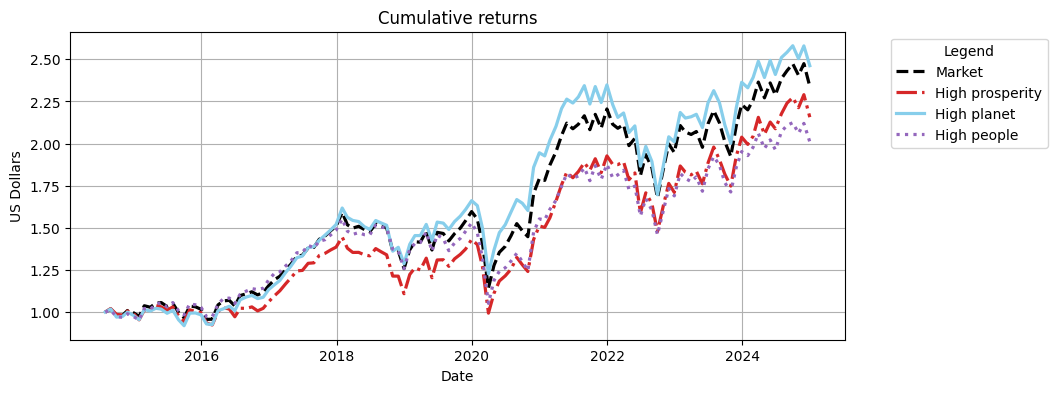

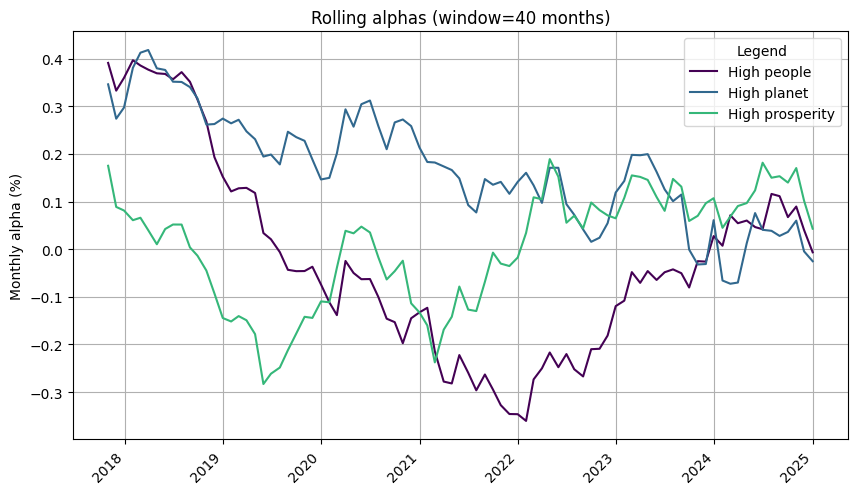

,1m,3m,YTD,1yr,3yr,5yr,10yr,Since launch
Market,-5.46%,-5.43%,4.82%,4.82%,6.07%,46.53%,134.96%,133.88%
High prosperity,-5.83%,-5.14%,5.82%,5.82%,11.92%,50.72%,117.70%,115.64%
High planet,-4.56%,-4.59%,4.17%,4.17%,4.86%,48.22%,151.26%,146.18%
High people,-5.17%,-5.36%,2.96%,2.96%,7.12%,31.47%,106.58%,100.99%


,Sharpe,VaR 1%,Max Drawdown,Alpha,p-value(alpha)
Market,0.56,-10.57%,-28.39%,,
High prosperity,0.50,-12.24%,-31.26%,0.06,0.560
High planet,0.59,-11.13%,-27.77%,0.17,0.120
High people,0.48,-10.21%,-32.26%,0.04,0.690


<Axes: title={'center': 'Rolling Annualised Sharpe (24-month window)'}, ylabel='Sharpe'>

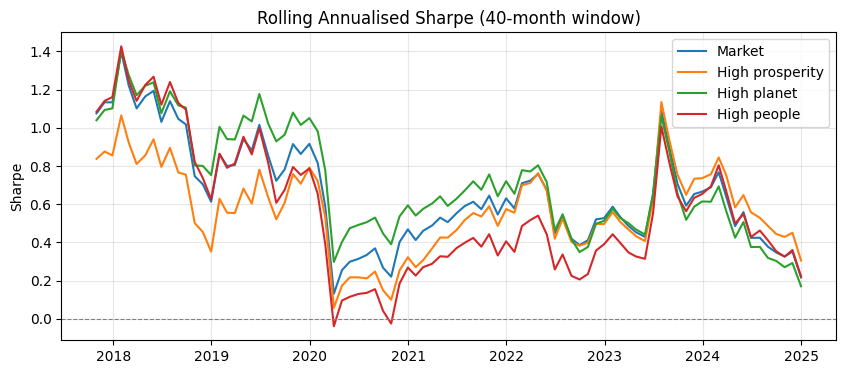

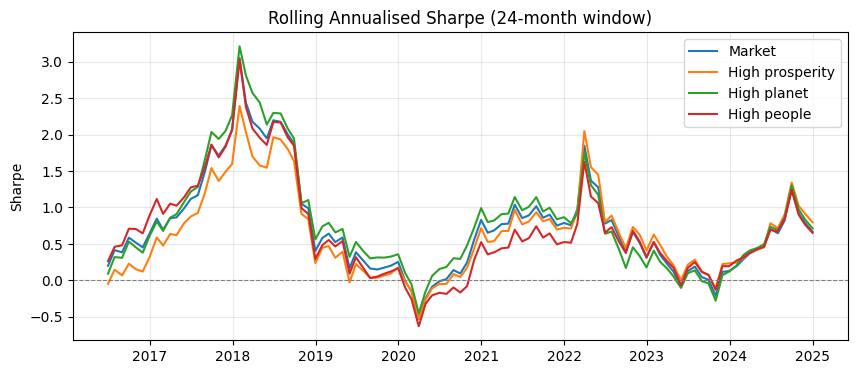

In [207]:
from functions.Strategy_Perfomance import StrategyPerformance
from functions.fama_french import plot_rolling_alpha_function



start_date = str(portfolio_returns.index[0])[:7]
end_date = str(portfolio_returns.index[-1])[:7]

sp = StrategyPerformance(portfolio_returns, ff3_parts_df=ff3_parts_df)


cumulative_table = sp.cumulative_performance_table(
    csv_path=f"./output/strategy_cumulative_performance_{start_date}-{end_date}.csv")

risk_table = sp.performance_risk_metrics_table(
    csv_path=f"./output/strategy_performance_metrics_{start_date}-{end_date}.csv")



sp.plot_cumulative_returns(
    title="Cumulative returns",
    tight_layout_rect = (0, 5, 100, 0.9),
    save_path=f"./output/img/cumulative_returns_{start_date}-{end_date}.png"
)

# Note: sector-split alpha is appended later once `sector_portfolio_returns` exists.
plot_rolling_alpha_function(
    rolling_alphas,
    title="Rolling alphas (window=40 months)",
    save_path="./output/img/rolling_alphas_{start_date}-{end_date}.png",
)

display(cumulative_table)
display(risk_table)


sp.plot_rolling_sharpe(window=40, save_path=f"./output/img/strategy_rolling_sharpe_40m_{start_date}-{end_date}.png")
#sp.plot_rolling_sharpe(window=60, save_path=f"./output/img/strategy_rolling_sharpe_60m_{start_date}-{end_date}.png")
sp.plot_rolling_sharpe(window=24, save_path=f"./output/img/strategy_rolling_sharpe_24m_{start_date}-{end_date}.png")


# 7. Portfolio Constituents

### Portfolio constituents — category mix (`PortfolioConstituents`)

Uses `signal_2_simple_quantiles_constituents` and `global_universe` to inspect **Industry**, **`loc`**, and **MacroRegion**: line charts of stock counts over time (default = last quantile `p_k`, same as `constituents[i][-1]`) and donut charts for the **final** formation month. Optional: `analyse_all_portfolios_at_once=True` unions all `p_1`…`p_k`; `all_sub_portfolios=True` plots one subplot per quantile.


The following only inspects the high transformation

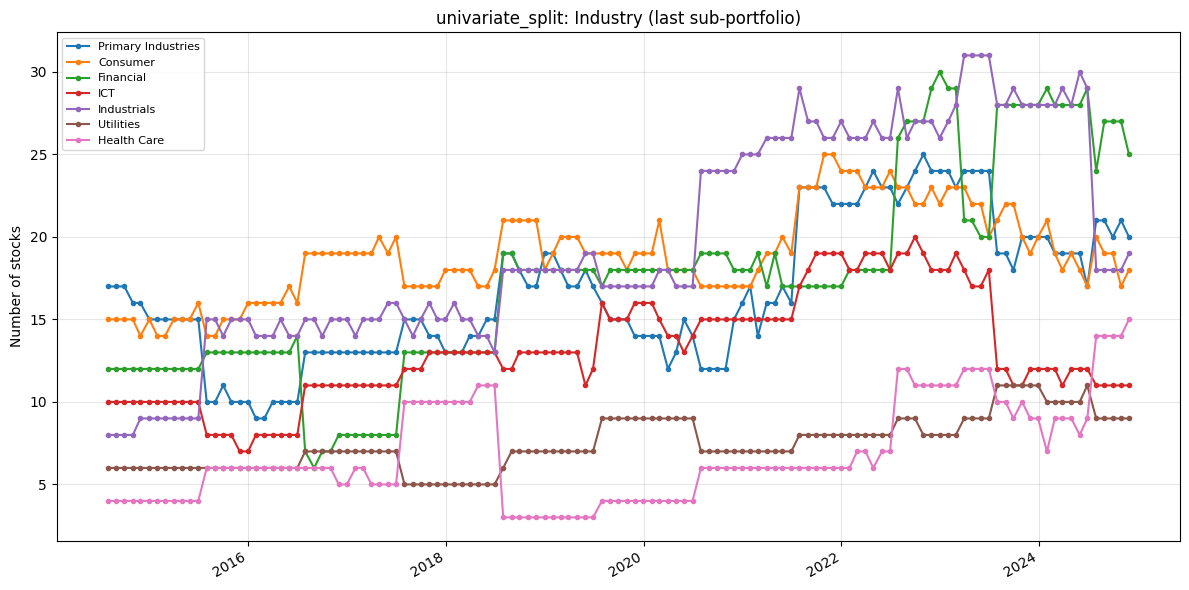

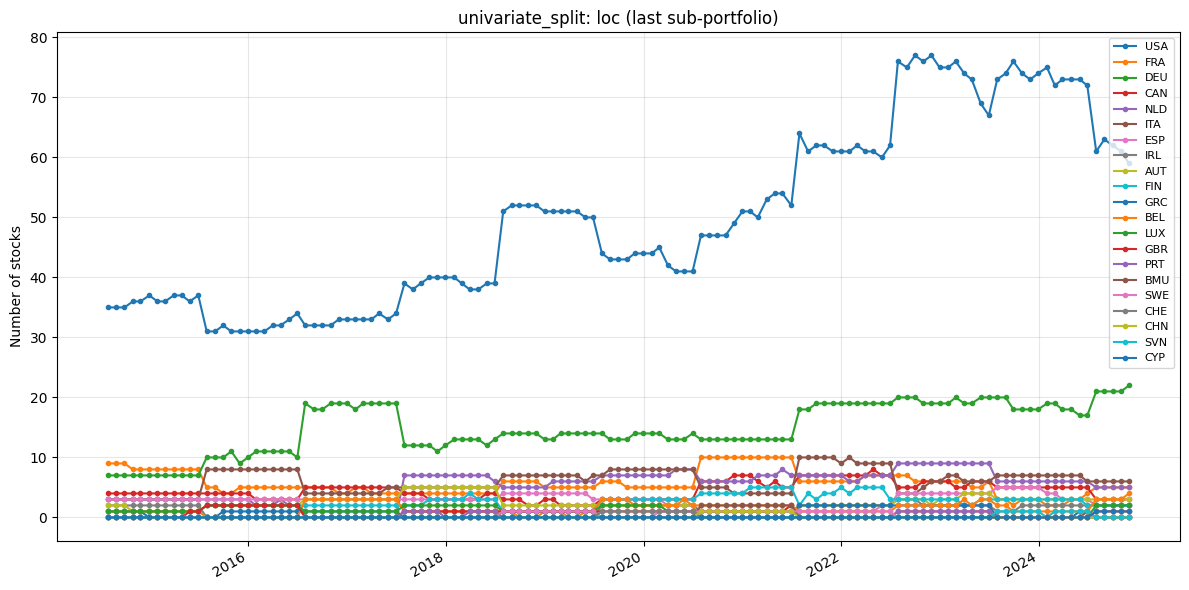

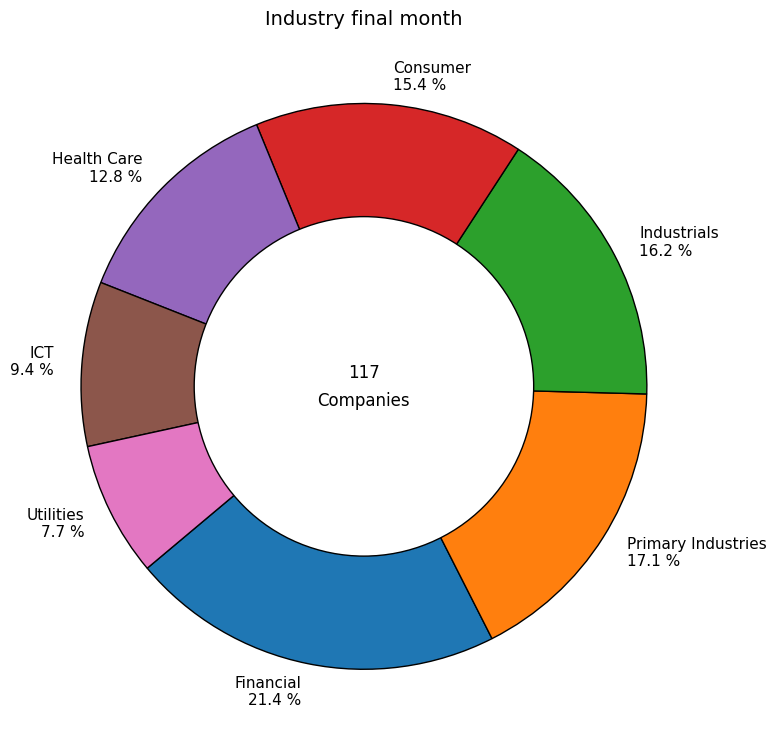

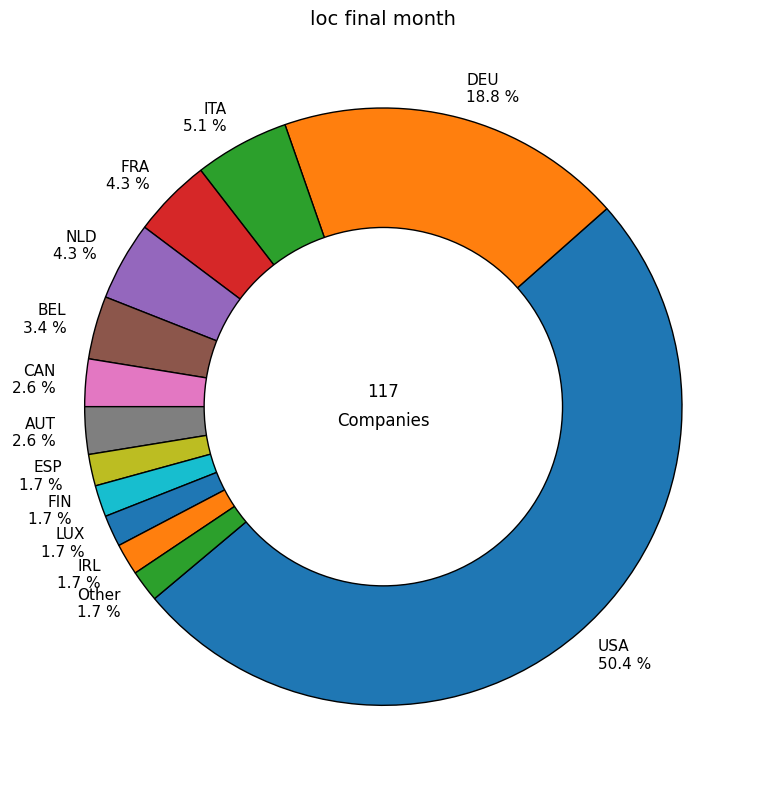

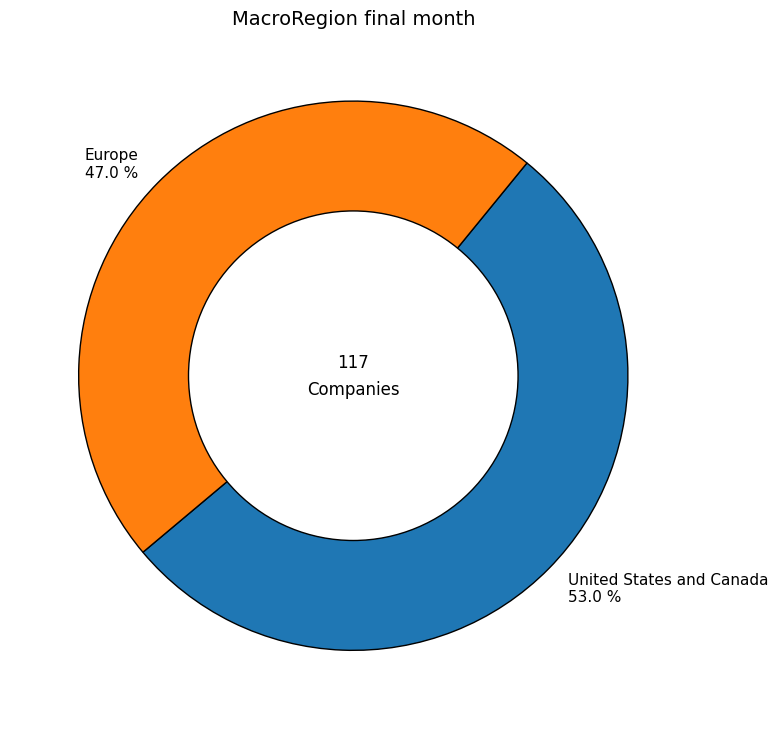

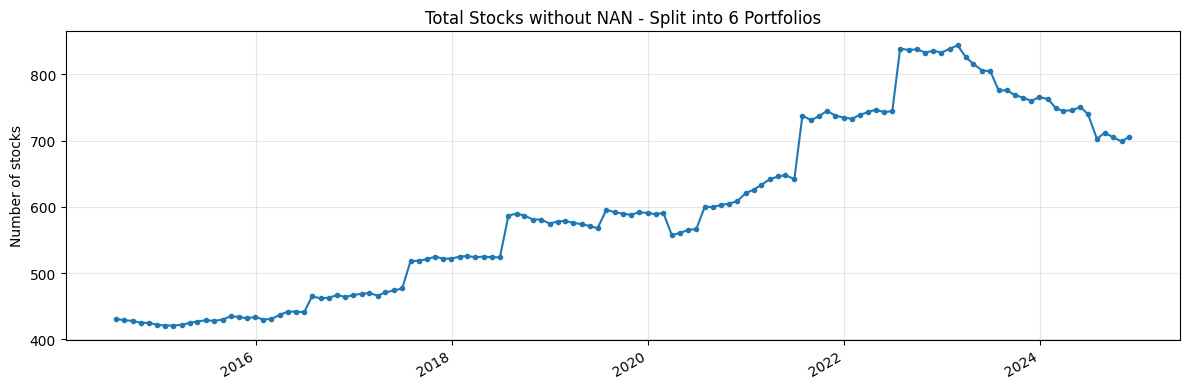

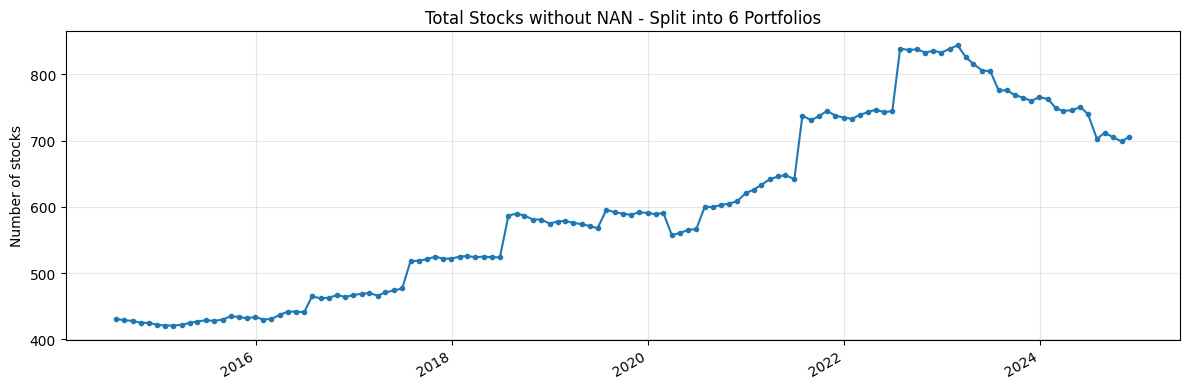

In [208]:
from IPython.display import display
from functions.Portfolio_Constituents import PortfolioConstituents

pc2 = PortfolioConstituents(
    signal_2_simple_quantiles_constituents,
    global_universe,
    portfolio_type="univariate_split",
)




_dates, wide_industry = pc2._counts_by_category_over_time(
    "Industry",
    portfolio_key=None,  # ignored when analyse_all_portfolios_at_once=True
    analyse_all_portfolios_at_once=False,
)

pc2.run_all_plots(save=True, show=True)

# Options:
#pc2.run_all_plots(analyse_all_portfolios_at_once=True, save=True, show=True)
#pc2.run_all_plots(all_sub_portfolios=True, save=True, show=True)
# Plot (like your snippet)
pc2.total_stocks_over_time(title=f"Total Stocks without NAN - Split into {no_simple_quantiles} Portfolios")
